In [2]:
!pip install torch

In [3]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 918.0 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.1 MB/s eta 0:00:0000:0100:01


In [4]:
!pip install networkx pandas scikit-learn seaborn matplotlib numpy category-encoders

In [5]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
import torch as th
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import from_networkx
from torch_geometric.data import Data
import networkx as nx
import pandas as pd
import socket
import struct
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import class_weight
import category_encoders as ce



In [6]:
data = pd.read_csv(
    '/kaggle/input/datasets/gaurkumarsoni/ton-iot/combined_output.csv',
                  engine = 'pyarrow')

In [7]:
data

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,0,0,-,-,-,bad_UDP_checksum,-,F,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22339016,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000011,0,0,...,0,0,-,-,-,-,-,-,1,dos
22339017,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000016,0,0,...,0,0,-,-,-,-,-,-,1,dos
22339018,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000113,0,0,...,0,0,-,-,-,-,-,-,1,dos
22339019,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000088,0,0,...,0,0,-,-,-,-,-,-,1,dos


In [8]:
print(data.columns.tolist())

['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_referrer', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']


In [9]:
data.type.value_counts()

type
scanning      7140161
ddos          6165008
dos           3375328
xss           2108944
password      1718568
normal         796380
backdoor       508116
injection      452659
ransomware      72805
mitm             1052
Name: count, dtype: int64

In [10]:
data.http_trans_depth.value_counts()

http_trans_depth
-     22314692
1        24282
2           31
10           2
3            2
4            2
5            2
6            2
7            2
8            2
9            2
Name: count, dtype: int64

In [11]:
data.shape

(22339021, 46)

In [12]:
data.drop(columns=['http_request_body_len','http_orig_mime_types','http_response_body_len','ssl_cipher','http_trans_depth','http_resp_mime_types','http_version','http_method','ssl_resumed','ssl_version','ssl_established','http_status_code'],inplace=True)

In [13]:
data

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,ssl_subject,ssl_issuer,http_uri,http_referrer,http_user_agent,weird_name,weird_addl,weird_notice,label,type
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,-,-,-,-,-,bad_TCP_checksum,-,F,0,normal
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,0,normal
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,-,-,-,-,-,bad_TCP_checksum,-,F,0,normal
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,0,normal
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,-,-,-,-,-,bad_UDP_checksum,-,F,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22339016,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000011,0,0,...,-,-,-,-,-,-,-,-,1,dos
22339017,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000016,0,0,...,-,-,-,-,-,-,-,-,1,dos
22339018,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000113,0,0,...,-,-,-,-,-,-,-,-,1,dos
22339019,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000088,0,0,...,-,-,-,-,-,-,-,-,1,dos


In [14]:
data.drop(columns=['http_referrer'], inplace=True)

In [15]:
data.shape

(22339021, 33)

In [16]:
mitm = data[data['type'] == 'mitm'].copy()
ransomware = data[data['type'] == 'ransomware'].copy() # created two dfs of mitm and ransomware class


In [17]:
data.shape

(22339021, 33)

In [18]:
mask = data['type'].isin(['mitm', 'ransomware'])
data = data[~mask]  # keeping mitm and ransomware classes seperate from the data(df)

In [19]:
ransomware

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,dns_rejected,ssl_subject,ssl_issuer,http_uri,http_user_agent,weird_name,weird_addl,weird_notice,label,type
14495262,1556423390,192.168.1.37,42438,34.230.157.88,443,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
14495263,1556423390,192.168.1.33,37242,34.230.157.88,443,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
14495265,1556423390,192.168.1.33,37242,34.230.157.88,443,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
14495266,1556423390,192.168.1.37,42438,34.230.157.88,443,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
14495267,1556423390,192.168.1.37,42438,34.230.157.88,443,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14763297,1556429194,192.168.1.37,38131,192.168.1.193,445,tcp,-,0.000029,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
14763780,1556429475,192.168.1.37,44413,13.55.50.68,123,udp,-,0.012730,48,48,...,-,-,-,-,-,-,-,-,1,ransomware
14763781,1556429477,192.168.1.33,39296,203.14.129.10,123,udp,-,0.032825,48,48,...,-,-,-,-,-,-,-,-,1,ransomware
14767007,1556431523,192.168.1.37,37268,13.55.50.68,123,udp,-,0.012950,48,48,...,-,-,-,-,-,-,-,-,1,ransomware


In [20]:
data.type.value_counts()

type
scanning     7140161
ddos         6165008
dos          3375328
xss          2108944
password     1718568
normal        796380
backdoor      508116
injection     452659
Name: count, dtype: int64

In [21]:
data = data.sample(frac=0.1,random_state = 123)

In [22]:
data.shape

(2226516, 33)

In [23]:
data = pd.concat([data,mitm,ransomware], axis=0, ignore_index=True)

In [24]:
data.type.value_counts()

type
scanning      713432
ddos          616497
dos           337158
xss           210977
password      172355
normal         79722
ransomware     72805
backdoor       51005
injection      45370
mitm            1052
Name: count, dtype: int64

In [25]:
data

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,dns_rejected,ssl_subject,ssl_issuer,http_uri,http_user_agent,weird_name,weird_addl,weird_notice,label,type
0,1556153545,192.168.1.30,4933,192.168.1.190,4933,tcp,-,0.000115,0,0,...,-,-,-,-,-,-,-,-,1,dos
1,1556027748,192.168.1.31,34613,192.168.1.195,1052,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,scanning
2,1556216632,192.168.1.30,58558,192.168.1.194,80,tcp,-,46.368270,0,0,...,-,-,-,-,-,-,-,-,1,ddos
3,1556088785,192.168.1.32,33150,192.168.1.180,13737,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,scanning
4,1556262331,192.168.1.190,51155,80.58.104.181,53,udp,dns,5.224819,52,104,...,F,-,-,-,-,-,-,-,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300368,1556429194,192.168.1.37,38131,192.168.1.193,445,tcp,-,0.000029,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
2300369,1556429475,192.168.1.37,44413,13.55.50.68,123,udp,-,0.012730,48,48,...,-,-,-,-,-,-,-,-,1,ransomware
2300370,1556429477,192.168.1.33,39296,203.14.129.10,123,udp,-,0.032825,48,48,...,-,-,-,-,-,-,-,-,1,ransomware
2300371,1556431523,192.168.1.37,37268,13.55.50.68,123,udp,-,0.012950,48,48,...,-,-,-,-,-,-,-,-,1,ransomware


In [26]:
data['src_ip'] = data.src_ip.apply(str)
data['src_port'] = data.src_port.apply(str)
data['dst_ip'] = data.dst_ip.apply(str)
data['dst_port'] = data.dst_port.apply(str)

In [27]:
data['src_ip'] = data['src_ip'] + ':' + data['src_port']
data['dst_ip'] = data['dst_ip'] + ':' + data['dst_port']

In [28]:
data

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,dns_rejected,ssl_subject,ssl_issuer,http_uri,http_user_agent,weird_name,weird_addl,weird_notice,label,type
0,1556153545,192.168.1.30:4933,4933,192.168.1.190:4933,4933,tcp,-,0.000115,0,0,...,-,-,-,-,-,-,-,-,1,dos
1,1556027748,192.168.1.31:34613,34613,192.168.1.195:1052,1052,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,scanning
2,1556216632,192.168.1.30:58558,58558,192.168.1.194:80,80,tcp,-,46.368270,0,0,...,-,-,-,-,-,-,-,-,1,ddos
3,1556088785,192.168.1.32:33150,33150,192.168.1.180:13737,13737,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,-,-,1,scanning
4,1556262331,192.168.1.190:51155,51155,80.58.104.181:53,53,udp,dns,5.224819,52,104,...,F,-,-,-,-,-,-,-,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300368,1556429194,192.168.1.37:38131,38131,192.168.1.193:445,445,tcp,-,0.000029,0,0,...,-,-,-,-,-,-,-,-,1,ransomware
2300369,1556429475,192.168.1.37:44413,44413,13.55.50.68:123,123,udp,-,0.012730,48,48,...,-,-,-,-,-,-,-,-,1,ransomware
2300370,1556429477,192.168.1.33:39296,39296,203.14.129.10:123,123,udp,-,0.032825,48,48,...,-,-,-,-,-,-,-,-,1,ransomware
2300371,1556431523,192.168.1.37:37268,37268,13.55.50.68:123,123,udp,-,0.012950,48,48,...,-,-,-,-,-,-,-,-,1,ransomware


In [29]:
data.drop(columns=['src_port','dst_port','http_uri','weird_name','weird_addl','weird_notice','dns_query','ssl_subject','ssl_issuer','http_user_agent','label'],inplace=True)

In [30]:
data.rename(columns={"type": "label"},inplace = True)
le = LabelEncoder()
le.fit(data.label.values)
data['label'] = le.transform(data['label'])

In [31]:
data['label']

0          2
1          8
2          1
3          8
4          5
          ..
2300368    7
2300369    7
2300370    7
2300371    7
2300372    7
Name: label, Length: 2300373, dtype: int64

In [32]:
label = data.label

In [33]:
print(label)
type(label)

0          2
1          8
2          1
3          8
4          5
          ..
2300368    7
2300369    7
2300370    7
2300371    7
2300372    7
Name: label, Length: 2300373, dtype: int64


pandas.core.series.Series

In [34]:
data.drop(columns=['label'],inplace = True)

In [35]:
data

,ts,src_ip,dst_ip,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,...,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected
0,1556153545,192.168.1.30:4933,192.168.1.190:4933,tcp,-,0.000115,0,0,REJ,0,...,40,1,40,0,0,0,-,-,-,-
1,1556027748,192.168.1.31:34613,192.168.1.195:1052,tcp,-,0.000000,0,0,S0,0,...,44,0,0,0,0,0,-,-,-,-
2,1556216632,192.168.1.30:58558,192.168.1.194:80,tcp,-,46.368270,0,0,S1,0,...,320,5,300,0,0,0,-,-,-,-
3,1556088785,192.168.1.32:33150,192.168.1.180:13737,tcp,-,0.000000,0,0,S0,0,...,48,0,0,0,0,0,-,-,-,-
4,1556262331,192.168.1.190:51155,80.58.104.181:53,udp,dns,5.224819,52,104,SF,0,...,80,1,132,1,28,0,F,F,F,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300368,1556429194,192.168.1.37:38131,192.168.1.193:445,tcp,-,0.000029,0,0,S0,0,...,120,0,0,0,0,0,-,-,-,-
2300369,1556429475,192.168.1.37:44413,13.55.50.68:123,udp,-,0.012730,48,48,SF,0,...,76,1,76,0,0,0,-,-,-,-
2300370,1556429477,192.168.1.33:39296,203.14.129.10:123,udp,-,0.032825,48,48,SF,0,...,76,1,76,0,0,0,-,-,-,-
2300371,1556431523,192.168.1.37:37268,13.55.50.68:123,udp,-,0.012950,48,48,SF,0,...,76,1,76,0,0,0,-,-,-,-


In [36]:
scaler = StandardScaler()

In [37]:
data =  pd.concat([data, label], axis=1)

In [38]:
data

,ts,src_ip,dst_ip,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,...,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,label
0,1556153545,192.168.1.30:4933,192.168.1.190:4933,tcp,-,0.000115,0,0,REJ,0,...,1,40,0,0,0,-,-,-,-,2
1,1556027748,192.168.1.31:34613,192.168.1.195:1052,tcp,-,0.000000,0,0,S0,0,...,0,0,0,0,0,-,-,-,-,8
2,1556216632,192.168.1.30:58558,192.168.1.194:80,tcp,-,46.368270,0,0,S1,0,...,5,300,0,0,0,-,-,-,-,1
3,1556088785,192.168.1.32:33150,192.168.1.180:13737,tcp,-,0.000000,0,0,S0,0,...,0,0,0,0,0,-,-,-,-,8
4,1556262331,192.168.1.190:51155,80.58.104.181:53,udp,dns,5.224819,52,104,SF,0,...,1,132,1,28,0,F,F,F,F,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300368,1556429194,192.168.1.37:38131,192.168.1.193:445,tcp,-,0.000029,0,0,S0,0,...,0,0,0,0,0,-,-,-,-,7
2300369,1556429475,192.168.1.37:44413,13.55.50.68:123,udp,-,0.012730,48,48,SF,0,...,1,76,0,0,0,-,-,-,-,7
2300370,1556429477,192.168.1.33:39296,203.14.129.10:123,udp,-,0.032825,48,48,SF,0,...,1,76,0,0,0,-,-,-,-,7
2300371,1556431523,192.168.1.37:37268,13.55.50.68:123,udp,-,0.012950,48,48,SF,0,...,1,76,0,0,0,-,-,-,-,7


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
     data, label, test_size=0.3, random_state=42,stratify= label)

In [40]:
X_train

,ts,src_ip,dst_ip,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,...,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,label
581044,1556359890,192.168.1.35:52700,192.168.1.195:80,tcp,-,0.566189,2956,3565,SF,0,...,5,3765,0,0,0,-,-,-,-,9
696989,1556356513,192.168.1.39:54544,192.168.1.195:80,tcp,http,0.064340,407,1282,SF,0,...,5,1494,0,0,0,-,-,-,-,9
315706,1556076723,192.168.1.31:44004,192.168.1.169:3389,tcp,-,0.056205,74,19,RSTRH,0,...,3,139,0,0,0,-,-,-,-,8
399567,1556076964,192.168.1.31:56874,192.168.1.190:18040,tcp,-,0.000169,0,0,REJ,0,...,1,40,0,0,0,-,-,-,-,8
840362,1556140131,192.168.1.30:1934,192.168.1.194:1934,tcp,-,0.000129,0,0,REJ,0,...,1,40,0,0,0,-,-,-,-,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585132,1556366748,192.168.1.35:51554,176.28.50.165:80,tcp,http,1.114653,227,322,SF,0,...,4,538,0,0,0,-,-,-,-,9
163122,1556307295,192.168.1.33:51412,192.168.1.195:80,tcp,http,0.009875,155,978,SF,0,...,4,1150,0,0,0,-,-,-,-,6
1543135,1556025742,192.168.1.30:42912,192.168.1.49:1782,tcp,-,0.000000,0,0,S0,0,...,0,0,0,0,0,-,-,-,-,8
1147170,1556141091,192.168.1.30:2151,192.168.1.190:2151,tcp,-,0.000119,0,0,REJ,0,...,1,40,0,0,0,-,-,-,-,2


In [41]:
encoder = ce.TargetEncoder(cols=['proto','service','conn_state','dns_qclass','dns_qtype','dns_rcode','dns_AA','dns_RD','dns_RA','dns_rejected'])
encoder.fit(X_train, y_train)
X_train = encoder.transform(X_train)

In [42]:
X_train.dtypes

ts                int64
src_ip           object
dst_ip           object
proto           float64
service         float64
duration        float64
src_bytes        object
dst_bytes         int64
conn_state      float64
missed_bytes      int64
src_pkts          int64
src_ip_bytes      int64
dst_pkts          int64
dst_ip_bytes      int64
dns_qclass      float64
dns_qtype       float64
dns_rcode       float64
dns_AA          float64
dns_RD          float64
dns_RA          float64
dns_rejected    float64
label             int64
dtype: object

In [43]:
bad = pd.to_numeric(X_train['src_bytes'], errors='coerce').isna()

print(X_train.loc[bad, 'src_bytes'].unique())

['0.0.0.0']


In [44]:
X_train['src_bytes'] = X_train['src_bytes'].replace('0.0.0.0', 0)
X_train['src_bytes'] = pd.to_numeric(X_train['src_bytes'])

In [45]:
cols_to_norm = X_train.iloc[:, 3:].columns.drop('label')

X_train[cols_to_norm] = X_train[cols_to_norm].astype('float32')

X_train[cols_to_norm] = scaler.fit_transform(X_train[cols_to_norm])

In [46]:
print(X_train[cols_to_norm].select_dtypes(exclude='number').columns)

Index([], dtype='object')


In [47]:
print(X_train[cols_to_norm].dtypes)

proto           float32
service         float32
duration        float32
src_bytes       float32
dst_bytes       float32
conn_state      float32
missed_bytes    float32
src_pkts        float32
src_ip_bytes    float32
dst_pkts        float32
dst_ip_bytes    float32
dns_qclass      float32
dns_qtype       float32
dns_rcode       float32
dns_AA          float32
dns_RD          float32
dns_RA          float32
dns_rejected    float32
dtype: object


In [48]:
print(X_train['src_bytes'].head(20))
print(X_train['src_bytes'].dtype)

581044     -0.026828
696989     -0.026903
315706     -0.026913
399567     -0.026915
840362     -0.026915
1601369    -0.026915
1489569    -0.026915
1560591    51.618111
471173     -0.026915
1403400    -0.026915
105677     -0.026915
2280102    -0.026915
1553454    -0.026915
1357580    -0.026915
1268245    -0.026915
1522162    -0.026915
193111     -0.026915
601260     -0.026915
1416448    -0.026915
1323812    -0.026915
Name: src_bytes, dtype: float32
float32


In [49]:
X_train['h'] = X_train[ cols_to_norm ].values.tolist()

In [50]:
X_train = X_train.sort_values(by='ts')

In [51]:
len(np.unique(X_train['ts'].values))

210068

In [52]:
y = X_train['label']

In [53]:
day_ids = X_train['ts'] // 86400
time_windows = []

for day, group_index in day_ids.groupby(day_ids):
    group = X_train.loc[group_index.index]
    if len(group) > 0:
        if len(group) > 20000:
            label_counts = group['label'].value_counts(normalize=True)
            sample_counts = (label_counts * 20000).astype(int)

            sampled_parts = []
            for label, count in sample_counts.items():
                subset = group[group['label'] == label]
                if len(subset) > 0:
                    sampled = subset.sample(
                        n=min(count, len(subset)),
                        random_state=42
                    )
                    sampled_parts.append(sampled)

            sampled_group = pd.concat(sampled_parts).sample(frac=1, random_state=42)
            time_windows.append(sampled_group.copy())
        else:
            time_windows.append(group.copy())

print("Number of valid time windows after partitioning by ts：", len(time_windows))

Number of valid time windows after partitioning by ts： 10


In [54]:
all_data_concat = pd.concat(time_windows, ignore_index=True)
unique_ips = pd.unique(all_data_concat[['src_ip', 'dst_ip']].values.ravel())
unique_ips.sort()

In [55]:
ip_to_id = {ip: i for i, ip in enumerate(unique_ips)}
id_to_ip = {i: ip for i, ip in enumerate(unique_ips)}

num_global_nodes = len(unique_ips)
print(f"Total number of globally unique nodes: {num_global_nodes}")

Total number of globally unique nodes: 113990


In [56]:
all_nodes = pd.unique(all_data_concat[['src_ip', 'dst_ip']].values.ravel())

In [57]:
%%time
time_graphs = []

print("2. Initializing PyG graph objects...")
for t, tw in enumerate(time_windows):
    tw_mapped = tw.copy()
    tw_mapped['src_id'] = tw_mapped['src_ip'].map(ip_to_id)
    tw_mapped['dst_id'] = tw_mapped['dst_ip'].map(ip_to_id)

    G_nx = nx.from_pandas_edgelist(
        tw_mapped,
        source="src_id",
        target="dst_id",
        edge_attr=['h', 'ts', 'label'],
        create_using=nx.MultiDiGraph()
    )

    current_graph_nodes = sorted(list(G_nx.nodes()))
    
    H = nx.MultiDiGraph()
    H.add_nodes_from(current_graph_nodes)
    H.add_edges_from(G_nx.edges(data=True))
    
    G_pyg = from_networkx(H)

    num_nodes_local = G_pyg.num_nodes
    edge_dim = G_pyg.h.shape[1] if len(G_pyg.h.shape) > 1 else 1
    
    x = th.ones((num_nodes_local, edge_dim), dtype=th.float)
    edge_attr = G_pyg.h
    edge_attr = th.nan_to_num(edge_attr, nan=0.0)

    data = Data(
        x=x,
        edge_index=G_pyg.edge_index,
        edge_attr=edge_attr,
        label=G_pyg.label
    )

    if hasattr(G_pyg, 'ts'):
        data.ts = G_pyg.ts
    else:
        data.ts = th.zeros(data.num_edges, dtype=th.float)


    data.global_node_ids = th.tensor(current_graph_nodes, dtype=th.long)

    time_graphs.append(data)

print(f"Composition complete, total no. of{len(time_graphs)} time slices.")

2. Initializing PyG graph objects...
Composition complete, total no. of10 time slices.
CPU times: user 8.07 s, sys: 132 ms, total: 8.2 s
Wall time: 8.08 s


In [58]:
print("3. Starting calculation of average node weights...")

def get_gca_node_weights_exact(edge_index, num_nodes=None):

    edge_index_ = to_undirected(edge_index)
    if num_nodes is None:
        num_nodes = edge_index_.max().item() + 1
    deg = degree(edge_index_[1], num_nodes=num_nodes).float()
    
    s = th.log(deg)
    
    s_max = s.max()
    s_mean = s.mean()
    
    denominator = s_max - s_mean
    if denominator == 0:
        weights = th.ones_like(s)
    else:
        weights = (s_max - s) / denominator
        
    return weights

3. Starting calculation of average node weights...


In [59]:
print("3.Start computing average node weights (Exact GCA Logic)...")

global_sum = th.zeros(num_global_nodes)
global_count = th.zeros(num_global_nodes)

3.Start computing average node weights (Exact GCA Logic)...


In [60]:
from torch_geometric.utils import from_networkx, degree, to_undirected

In [61]:
for t, data in enumerate(time_graphs):
    local_weights = get_gca_node_weights_exact(data.edge_index, num_nodes=data.num_nodes)
    
    global_ids = data.global_node_ids
    
    global_sum[global_ids] += local_weights.cpu()
    global_count[global_ids] += 1

In [62]:
final_avg_weights = global_sum / global_count

In [63]:
print("Weight calculation completed.")
print(f"final_avg_weights shape: {final_avg_weights.shape}")

Weight calculation completed.
final_avg_weights shape: torch.Size([113990])


In [64]:
def get_gca_feature_mask_exact(
        z,
        data,
        global_avg_weights,
        base_strength=0.2,
        noise_scale=0.1,
        min_corrupt=0.01,
        max_corrupt=0.3       
    ):

    if global_avg_weights.device != z.device:
        global_avg_weights = global_avg_weights.to(z.device)

    active_ids = data.global_node_ids
    w = global_avg_weights[active_ids]

    w_min, w_max = w.min(), w.max()
    norm_w = (w - w_min) / (w_max - w_min + 1e-6)
    
    corrupt_strength = base_strength * norm_w

    corrupt_strength = corrupt_strength.clamp(min_corrupt, max_corrupt)

    corrupt_strength = corrupt_strength.unsqueeze(1)


    noise = torch.randn_like(z) * noise_scale

    z_pos = (1 - corrupt_strength) * z + corrupt_strength * noise

    return z_pos

In [65]:
def get_negative_feature_mask_exact(
        z, 
        data, 
        global_avg_weights, 
        base_strength=0.5,
        noise_scale=0.3,
        min_corrupt=0.05,
        max_corrupt=0.5
    ):

    if global_avg_weights.device != z.device:
        global_avg_weights = global_avg_weights.to(z.device)

    active_ids = data.global_node_ids
    w = global_avg_weights[active_ids]

    w_min, w_max = w.min(), w.max()
    inv_w = (w_max - w) / (w_max - w_min + 1e-6)

    corrupt_strength = base_strength * inv_w  

    corrupt_strength = corrupt_strength.clamp(min_corrupt, max_corrupt) 

    corrupt_strength = corrupt_strength.unsqueeze(1)

    noise = torch.randn_like(z) * noise_scale

    z_neg = (1 - corrupt_strength) * z + corrupt_strength * noise

    return z_neg

In [66]:
class MLPPredictor(nn.Module):
    def __init__(self, in_features, efeat, out_classes):
        super(MLPPredictor, self).__init__()
        self.lin1 = nn.Linear(in_features * 2 + efeat, in_features)
        self.dropout = nn.Dropout(0.5)
        self.lin2 = nn.Linear(in_features, out_classes)
    def forward(self, edge_index, emb, efeat, device):
        edge_index = edge_index.to(device)
        x = emb.to(device)
        efeat = efeat.to(device)
        h_u = x[edge_index[0]]
        h_v = x[edge_index[1]]
        h_cat = torch.cat([h_u, h_v, efeat], dim=1)

        h_mid = F.relu(self.lin1(h_cat))
        h_mid = self.dropout(h_mid)
        
        score = self.lin2(h_mid)
        
        return score

In [67]:
import torch.nn as nn

class TemporalPredictorLoss(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.predictor = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, feature_dim)
        )

    def forward(self, z_t, z_t_next, z_t_far, time_graphs, next_time_graphs, far_time_graphs, penalty_weight=0.05):

        z_t_pred_raw = self.predictor(z_t)


        z_t_pred = F.normalize(z_t_pred_raw, dim=-1)
        z_t_next_norm = F.normalize(z_t_next, dim=-1)
        z_t_far_norm  = F.normalize(z_t_far, dim=-1)

        ids_t     = time_graphs.global_node_ids.cpu().numpy()
        ids_next  = next_time_graphs.global_node_ids.cpu().numpy()
        ids_far   = far_time_graphs.global_node_ids.cpu().numpy()

        loss_align = torch.tensor(0.0, device=z_t.device)
        loss_uniform = torch.tensor(0.0, device=z_t.device)


        common_pos = np.intersect1d(ids_t, ids_next)

        if len(common_pos) > 0:
            idx_pos = torch.from_numpy(common_pos).to(z_t.device)

            anchor_pos = z_t_pred[idx_pos]
            target_pos = z_t_next_norm[idx_pos]


            sim_pos = (anchor_pos * target_pos).sum(dim=-1)

            loss_align = 2 - 2 * sim_pos.mean() 
            
        common_neg = np.intersect1d(ids_t, ids_far)

        if len(common_neg) > 0:
            idx_neg = torch.from_numpy(common_neg).to(z_t.device)

            anchor_neg = z_t_pred[idx_neg]
            target_neg = z_t_far_norm[idx_neg]

            sim_neg = (anchor_neg * target_neg).sum(dim=-1)

            margin = 0.1
            loss_uniform = F.relu(sim_neg - margin).mean()

        total_loss = loss_align + penalty_weight * loss_uniform

        return total_loss

In [68]:
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool, global_add_pool, SAGPooling
import torch
import torch.nn as nn
from torch_geometric.nn.inits import reset
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn import metrics
import pickle
import numpy as np
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops

class SAGELayer(MessagePassing):
    def __init__(self, ndim_in, edim, ndim_out, activation):
        super(SAGELayer, self).__init__(aggr='mean')
        self.W_msg = nn.Linear(ndim_in + edim, ndim_out)
        self.W_apply = nn.Linear(ndim_in + ndim_out, ndim_out)
        self.activation = activation
   
    def forward(self, x, edge_index, edge_attr, weight=None):
        
        
        if weight is not None:
            edge_attr=edge_attr*weight.unsqueeze(-1)
        
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        out = self.W_msg(out)
        out = torch.cat([x, out], dim=1)
        out = self.W_apply(out)
        return self.activation(out)
    
    def message(self, x_j, edge_attr):
        msg = torch.cat([x_j, edge_attr], dim=1)
        return msg
    
class SAGE(nn.Module):
    def __init__(self, ndim_in, ndim_out, edim, activation, dropout):
        super(SAGE, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(SAGELayer(ndim_in, edim, 128, activation))
        self.layers.append(SAGELayer(128, edim, ndim_out, activation))
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, edge_index, edge_attr, weight=None):

        for i, layer in enumerate(self.layers):
            if i != 0:
                x = self.dropout(x)   
            if weight is not None:
                x = layer(x, edge_index, edge_attr, weight)
            else:
                x = layer(x, edge_index, edge_attr)
        return x

In [69]:
import torch.nn.functional as F
class EGraphSAGE_LSTM_Model(nn.Module):
    def __init__(self, node_in_dim, edge_dim, gnn_out, lstm_hidden, dropout=0.1):
        super(EGraphSAGE_LSTM_Model, self).__init__()
        self.gnn = SAGE(node_in_dim, gnn_out, edge_dim, activation=F.relu, dropout=dropout)
        self.lstm_hidden = lstm_hidden
        self.lstm_cell = nn.LSTMCell(gnn_out, lstm_hidden)
        self.fuse = nn.Linear(node_in_dim + lstm_hidden, node_in_dim)
        self.dropout = nn.Dropout(dropout)
    
    def global_to_local(self, g, device):
        N_global = g.global_node_ids.max().item() + 1
        mapper = torch.full((N_global,), -1, dtype=torch.long, device=device)
        n_local = g.global_node_ids.size(0)
        mapper[g.global_node_ids] = torch.arange(n_local, device=device)
        return mapper
    
    def forward(self, time_graphs, device):
        
        state_h = {}
        state_c = {}
        all_graph_embs = {}
        print("preparing")
        num_nodes = len(all_nodes)
        hidden_dim = model.lstm_hidden
        node_emb_all = torch.ones(num_nodes, hidden_dim).to(device)
        for t in range(len(time_graphs)):
            g = time_graphs[t]
            x = g.x.to(device)
            edge_index = g.edge_index.to(device) 
            edge_attr = g.edge_attr.to(device)
            nodes = g.global_node_ids
            
            prev_h = []
            prev_c = []
            for n in nodes:
                if n in state_h:
                    prev_h.append(state_h[n])
                    prev_c.append(state_c[n])
                else:
                    prev_h.append(torch.zeros(lstm_hidden, device=x.device))
                    prev_c.append(torch.zeros(lstm_hidden, device=x.device))
            prev_h = torch.stack(prev_h, dim=0)
            prev_c = torch.stack(prev_c, dim=0)
            
            print(f"processing time step {t} ...")
            
            x_input = torch.cat([x, prev_h], dim=1)
            x_input = self.fuse(x_input)
            
            h_gnn = self.gnn(x_input, edge_index, edge_attr)
            h_time, c_time = self.lstm_cell(h_gnn, (prev_h, prev_c))
            for idx, n in enumerate(nodes):
                state_h[n.item()] = h_time[idx]
                state_c[n.item()] = c_time[idx]
            
            node_emb_all[nodes] = h_time.clone()
            all_graph_embs[t] = node_emb_all.clone()
            #mem_report("3")
            torch.cuda.empty_cache()
        return all_graph_embs
    
    def forward_gnn_only(self, g, device):
        x = g.x.to(device)
        edge_index = g.edge_index.to(device)
        edge_attr = g.h.to(device)
        
        h_gnn = self.gnn(x, edge_index, edge_attr)
        
        return h_gnn
    
    def forward_single(self, g, device):
        x = g.x.to(device)
        edge_index = g.edge_index.to(device)
        edge_attr = g.h.to(device)

        h0 = torch.zeros(x.size(0), self.lstm_hidden, device=device)
        c0 = torch.zeros(x.size(0), self.lstm_hidden, device=device)
        
        x_input = torch.cat([x, h0], dim=1)
        x_input = self.fuse(x_input)

        h_gnn = self.gnn(x_input, edge_index, edge_attr)
        h_time, c_time = self.lstm_cell(h_gnn, (h0, c0))

        return h_time


In [70]:
def spatial_contrastive_loss(z, edge_index, tau=0.5, num_neg=5):
    
    src, dst = edge_index
    z = F.normalize(z, dim=1)
    N = z.size(0)
    device = z.device
    
    pos_sim = (z[src] * z[dst]).sum(dim=1, keepdim=True) / tau
    
    
    adj_dict = {i: set() for i in range(N)}
    for s, d in zip(src.tolist(), dst.tolist()):
        adj_dict[s].add(d)
        adj_dict[d].add(s)
    
    neg_sims = []
    for i in range(src.size(0)):
        s = src[i].item()
        neg_nodes = set()
        while len(neg_nodes) < num_neg:
            candidate = torch.randint(0, N, (1,), device=z.device).item()
            if candidate != s and candidate not in adj_dict[s]:
                neg_nodes.add(candidate)
        neg_nodes = torch.tensor(sorted(neg_nodes), device=z.device)
        
        anchor = z[s].unsqueeze(0)
        neg_sim = (anchor * z[neg_nodes]).sum(dim=-1) / tau
        neg_sims.append(neg_sim)
        
    neg_sims = torch.stack(neg_sims)
    
    logits = torch.cat([pos_sim, neg_sims], dim=1)
    
    labels = torch.zeros(src.size(0), dtype=torch.long, device=z.device)
    
    loss = F.cross_entropy(logits, labels, reduction='mean')
    return loss

def corrupt_features(x, mask_prob=0.2, noise_scale=0.1):
    mask = (torch.rand_like(x) > mask_prob).float()
    x_masked = x * mask
    noise = torch.randn_like(x) * noise_scale
    x_corrupt = x_masked + noise
    
    return x_corrupt

def feature_contrastive_loss(z_active, data, final_avg_weights, temperature=0.2):
    z_pos = get_gca_feature_mask_exact(z_active, data, final_avg_weights)

    z_neg = get_negative_feature_mask_exact(z_active, data, final_avg_weights)

    anchor = F.normalize(z_active, dim=1)
    positive = F.normalize(z_pos, dim=1)
    negative = F.normalize(z_neg, dim=1)
    
    pos_sim = (anchor * positive).sum(dim=1) / temperature
    neg_sim = (anchor * negative).sum(dim=1) / temperature
    
    logits = torch.stack([pos_sim, neg_sim], dim=1)
    labels = torch.zeros(logits.shape[0], dtype=torch.long).to(anchor.device)
    
    loss = F.cross_entropy(logits, labels)
    return loss


In [71]:
import torch

def get_grad_norms(losses, shared_layer_params):
    if not isinstance(shared_layer_params, list):
        shared_layer_params = list(shared_layer_params)
    
    grads_norms = []
    
    for loss in losses:
        if loss == 0.0 or (isinstance(loss, torch.Tensor) and loss.item() == 0.0):
            grads_norms.append(0.0)
            continue
            
        if isinstance(loss, torch.Tensor) and not loss.requires_grad:
            grads_norms.append(0.0)
            continue

        try:
            grads = torch.autograd.grad(
                loss, 
                shared_layer_params, 
                retain_graph=True, 
                create_graph=False,
                allow_unused=True
            )

            total_norm = 0.0
            for g in grads:
                if g is not None:
                    total_norm += g.data.norm(2).item() ** 2
            total_norm = total_norm ** 0.5
            grads_norms.append(total_norm)
            
        except Exception as e:
            print(f"Warning: Grad calculation failed for loss {loss}. Defaulting to 0.0. Error: {e}")
            grads_norms.append(0.0)
            
    return grads_norms

In [72]:
def compute_grad_balanced_weights(grad_norm_A, grad_norm_B, grad_norm_C, epsilon=1e-8):
    g_a = float(grad_norm_A) if grad_norm_A is not None else 0.0
    g_b = float(grad_norm_B) if grad_norm_B is not None else 0.0
    g_c = float(grad_norm_C) if grad_norm_C is not None else 0.0

    if g_a <= 1e-12:
        w_a = 0.0
    else:
        w_a = g_a

    w_b = g_b
    w_c = g_c

    # 3. normalization
    total = w_a + w_b + w_c

    if total <= 1e-12:
        return (0.0, 0.5, 0.5)

    return (w_a / total, w_b / total, w_c / total)

In [73]:
import torch
import torch.nn.functional as F
from torch.optim import Adam

def train_model(model,  temporal_loss_module, time_graphs, optimizer, device, tau=0.5, num_neg=5, mask_prob=0.2, noise_scale=0.1, alpha=1.0, beta=1.0, gamma=1.0):
    model.train()
    temporal_loss_module.train()
    total_loss = 0
    all_graph_embs = []
    d1 = 1
    d2 = 4
    
    shared_params = list(model.fuse.parameters()) 

    all_graph_embs = model(time_graphs, device)
    
    alpha = 0.4
    beta = 0.3
    gamma=0.3
    
    for t in range(len(all_graph_embs)):
        print(t)
        all_graph_embs = model(time_graphs, device)
        z_t = all_graph_embs[t] 
        g = time_graphs[t]
        spatial_loss = spatial_contrastive_loss(z_t, g.edge_index, tau=tau, num_neg=num_neg)
        
        active_indices = g.global_node_ids
        z_t_active = z_t[active_indices]
        feature_loss = feature_contrastive_loss(z_t_active, g, final_avg_weights)

       
        if t + d2 < len(all_graph_embs):
            z_next = all_graph_embs[t + d1]
            z_far = all_graph_embs[t + d2]
            temporal_loss = temporal_loss_module(z_t, z_next, z_far, time_graphs[t],time_graphs[t+d1],time_graphs[t+d2])
        elif t - d2 >= 0:
            if t + d1 < len(all_graph_embs):
                z_next = all_graph_embs[t + d1]
                z_far = all_graph_embs[t - d2]
                temporal_loss = temporal_loss_module(z_t, z_next, z_far, time_graphs[t],time_graphs[t+d1],time_graphs[t-d2])
            else:
                temporal_loss = 0
        else:
            temporal_loss = 0
        print("temporal_loss", temporal_loss)
        print("spatial_loss", spatial_loss)
        print("feature_loss", feature_loss)
        grad_norms = get_grad_norms([temporal_loss, spatial_loss, feature_loss], shared_params)
        
        alpha, beta, gamma = compute_grad_balanced_weights(grad_norms[0], grad_norms[1], grad_norms[2])
    
        total_step_loss = alpha*temporal_loss + beta*spatial_loss + gamma*feature_loss
        
        optimizer.zero_grad()
        total_step_loss.backward()
        optimizer.step()
        total_loss += total_step_loss.item()
        print(f"Weights: {alpha:.2f}, {beta:.2f}, {gamma:.2f} | Grads: {grad_norms}")
    return total_loss / len(all_graph_embs)

In [74]:
%%time
import torch.nn.functional as F
device = 'cuda'if torch.cuda.is_available() else 'cpu'
ndim_in = 18
ndim_out = 128
edim = 18
lstm_hidden = 64
activation = F.relu
dropout = 0.15
model = EGraphSAGE_LSTM_Model(ndim_in, edim, ndim_out, lstm_hidden, dropout).to(device)
temporal_loss_module = TemporalPredictorLoss(lstm_hidden).to(device)
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(temporal_loss_module.parameters()), 
    lr=1e-3
)

epochs = 10
best_loss = float('inf')

for epoch in range(epochs):
    loss = train_model(
        model=model,
        temporal_loss_module =  temporal_loss_module,
        time_graphs=time_graphs,
        optimizer=optimizer,
        device=device,
        tau=0.3,
        num_neg=10,
        mask_prob=0.2,
        noise_scale=0.4,
        alpha=0.3,
        beta=0.4,
        gamma=0.3
    )
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.6f}")

    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), 'finaltimemulticlasslossabc2model_weights.pth')  # Save weights
        torch.save(model, 'finaltimemulticlasslossabc2model.pth')  # Save the whole model
        print(f"✅ Epoch {epoch+1}: The new best model has been saved (loss={best_loss:.6f})")

preparing
processing time step 0 ...
processing time step 1 ...
processing time step 2 ...
processing time step 3 ...
processing time step 4 ...
processing time step 5 ...
processing time step 6 ...
processing time step 7 ...
processing time step 8 ...
processing time step 9 ...
0
preparing
processing time step 0 ...
processing time step 1 ...
processing time step 2 ...
processing time step 3 ...
processing time step 4 ...
processing time step 5 ...
processing time step 6 ...
processing time step 7 ...
processing time step 8 ...
processing time step 9 ...
temporal_loss tensor(1.8758, device='cuda:0', grad_fn=<AddBackward0>)
spatial_loss tensor(2.4584, device='cuda:0', grad_fn=<NllLossBackward0>)
feature_loss tensor(0.9664, device='cuda:0', grad_fn=<NllLossBackward0>)
Weights: 0.73, 0.08, 0.19 | Grads: [0.19516746321871936, 0.022058376923857075, 0.05049939015063756]
1
preparing
processing time step 0 ...
processing time step 1 ...
processing time step 2 ...
processing time step 3 ...
pr

In [75]:
model = torch.load(
    'finaltimemulticlasslossabc2model.pth',
    map_location='cuda:0',
    weights_only=False
)

In [76]:
model

EGraphSAGE_LSTM_Model(
  (gnn): SAGE(
    (layers): ModuleList(
      (0-1): 2 x SAGELayer()
    )
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (lstm_cell): LSTMCell(128, 64)
  (fuse): Linear(in_features=82, out_features=18, bias=True)
  (dropout): Dropout(p=0.15, inplace=False)
)

In [77]:
G = nx.from_pandas_edgelist(
        X_train,
        source="src_ip",
        target="dst_ip",
        edge_attr=['h', 'ts', 'label'],
        create_using=nx.MultiDiGraph()
    )

train_PyG = from_networkx(G)

train_data_num_nodes = train_PyG.num_nodes
train_data_edge_dim = train_PyG.h.shape[1] if len(train_PyG.h.shape) > 1 else 1
train_data_x = torch.ones((train_data_num_nodes, train_data_edge_dim), dtype=torch.float)

train_data_edge_attr = train_PyG.h
train_data_edge_attr = torch.nan_to_num(train_data_edge_attr, nan=0.0)


train_data = Data(
    x=train_data_x,
    edge_index=train_PyG.edge_index,
    h=train_data_edge_attr,
    label=train_PyG.label
)

In [78]:
g1 = train_data
g1 = train_data.to('cuda:0')
device = "cuda"
model.eval()
embeds = model.forward_gnn_only(g1, device)

In [79]:
def compute_accuracy(pred, labels):
    return (pred.argmax(1) == labels).float().mean().item()

In [80]:
%%time
embs_train = F.normalize(embeds, p=2, dim=1)

train_lbls = g1['label']

xent = nn.CrossEntropyLoss()
log = MLPPredictor(128, 18, 10)
opt = th.optim.Adam(log.parameters(), lr=0.001, weight_decay=0.0001)
log.cuda()

for i in range(4000):
    log.train()
    with th.no_grad():
        embeds = model.forward_gnn_only(g1, device)
        embs_train = F.normalize(embeds, p=2, dim=1)
    opt.zero_grad()
        
    logits = log(g1.edge_index, embs_train, g1['h'], device)
    loss = xent(logits, train_lbls.long().cuda())
    print(i,' Training acc:', compute_accuracy(logits, train_lbls.long().cuda()))
    print('The loss is:{}'.format(loss))
    loss.backward(retain_graph=True)
    opt.step()

0  Training acc: 0.10284606367349625
The loss is:2.3145177364349365
1  Training acc: 0.13217857480049133
The loss is:2.2880663871765137
2  Training acc: 0.17143681645393372
The loss is:2.263028860092163
3  Training acc: 0.25010356307029724
The loss is:2.2388722896575928
4  Training acc: 0.3616034984588623
The loss is:2.2155258655548096
5  Training acc: 0.45816922187805176
The loss is:2.1925525665283203
6  Training acc: 0.5186321139335632
The loss is:2.169950246810913
7  Training acc: 0.5462977886199951
The loss is:2.1475582122802734
8  Training acc: 0.5563135743141174
The loss is:2.124704122543335
9  Training acc: 0.5567898750305176
The loss is:2.1017332077026367
10  Training acc: 0.553968608379364
The loss is:2.0784401893615723
11  Training acc: 0.5505629181861877
The loss is:2.0540552139282227
12  Training acc: 0.5471994876861572
The loss is:2.0293195247650146
13  Training acc: 0.542351245880127
The loss is:2.004338026046753
14  Training acc: 0.538148820400238
The loss is:1.978816628

In [81]:
X_test = encoder.transform(X_test)

In [82]:
X_test.dtypes

ts                int64
src_ip           object
dst_ip           object
proto           float64
service         float64
duration        float64
src_bytes        object
dst_bytes         int64
conn_state      float64
missed_bytes      int64
src_pkts          int64
src_ip_bytes      int64
dst_pkts          int64
dst_ip_bytes      int64
dns_qclass      float64
dns_qtype       float64
dns_rcode       float64
dns_AA          float64
dns_RD          float64
dns_RA          float64
dns_rejected    float64
label             int64
dtype: object

In [83]:
bad = pd.to_numeric(X_test['src_bytes'], errors='coerce').isna()

print(X_test.loc[bad, 'src_bytes'].unique())

['0.0.0.0']


In [84]:
X_test['src_bytes'] = X_test['src_bytes'].replace('0.0.0.0', 0)
X_test['src_bytes'] = pd.to_numeric(X_test['src_bytes'])

In [85]:
X_test[cols_to_norm] = scaler.transform(X_test[cols_to_norm])

In [86]:
X_test[cols_to_norm].dtypes

proto           float64
service         float64
duration        float64
src_bytes       float64
dst_bytes       float64
conn_state      float64
missed_bytes    float64
src_pkts        float64
src_ip_bytes    float64
dst_pkts        float64
dst_ip_bytes    float64
dns_qclass      float64
dns_qtype       float64
dns_rcode       float64
dns_AA          float64
dns_RD          float64
dns_RA          float64
dns_rejected    float64
dtype: object

In [87]:
X_test['h'] = X_test[ cols_to_norm ].values.tolist()

In [88]:
G_test = nx.from_pandas_edgelist(
        X_test,
        source="src_ip",
        target="dst_ip",
        edge_attr=['h', 'ts', 'label'],
        create_using=nx.MultiDiGraph()
    )

test_PyG = from_networkx(G_test)

test_data_num_nodes = test_PyG.num_nodes
test_data_edge_dim = test_PyG.h.shape[1] if len(test_PyG.h.shape) > 1 else 1
test_data_x = torch.ones((test_data_num_nodes, test_data_edge_dim), dtype=torch.float)

test_data_edge_attr = test_PyG.h
test_data_edge_attr = torch.nan_to_num(test_data_edge_attr, nan=0.0)


test_data = Data(
    x=test_data_x,
    edge_index=test_PyG.edge_index,
    h=test_data_edge_attr,
    label=test_PyG.label
)

In [89]:
import timeit


torch.cuda.synchronize()
start_time = timeit.default_timer()

model.eval()
test_embeds = model.forward_gnn_only(test_data, device)

torch.cuda.synchronize()
elapsed = timeit.default_timer() - start_time

In [90]:
print(str(elapsed) + ' seconds')

0.14928753200001665 seconds


In [91]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_lbls = test_data['label']
test_embeds_1 = F.normalize(test_embeds, p=2, dim=1)

logits = log(test_data.edge_index, test_embeds_1, test_data['h'].cuda(), device)
preds = th.argmax(logits, dim=1)
print('preds:{}'.format(preds))
print('test_lbls:{}'.format(test_lbls))
test_lbls = test_lbls.detach().cpu().numpy()
preds = preds.detach().cpu().numpy()

test_lbls = le.inverse_transform(test_lbls)
preds = le.inverse_transform(preds)


preds:tensor([1, 1, 1,  ..., 1, 5, 1], device='cuda:0')
test_lbls:tensor([1, 1, 1,  ..., 1, 5, 1])


In [92]:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45, fontsize=10)
        plt.yticks(tick_marks, target_names, fontsize=10)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.1f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    #plt.ylabel('True label')
    plt.xlabel('accuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

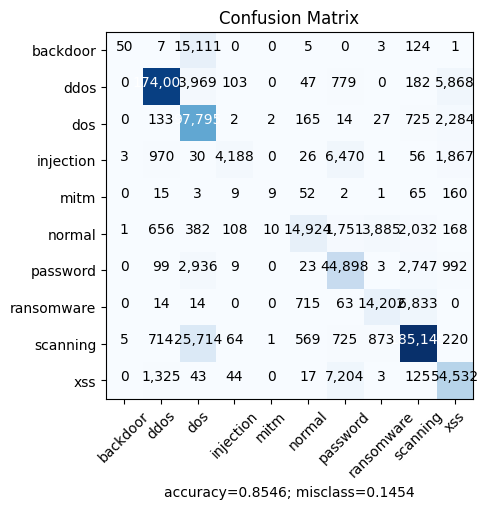

In [93]:
from sklearn.metrics import confusion_matrix

plot_confusion_matrix(cm = confusion_matrix(test_lbls, preds), 
                      normalize    = False,
                      target_names = np.unique(test_lbls),
                      title        = "Confusion Matrix")

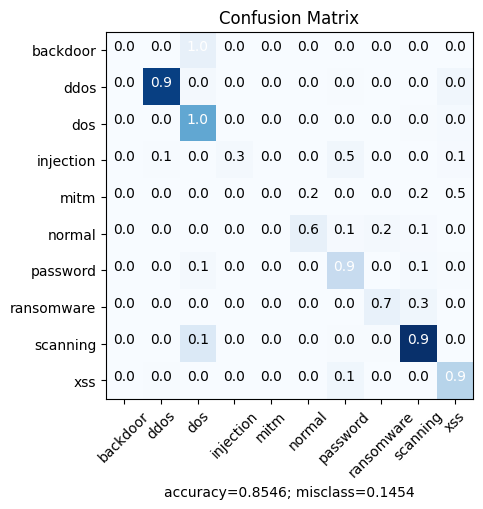

In [94]:
from sklearn.metrics import confusion_matrix

plot_confusion_matrix(cm = confusion_matrix(test_lbls, preds), 
                      normalize    = True,
                      target_names = np.unique(test_lbls),
                      title        = "Confusion Matrix")

In [95]:
from sklearn.metrics import classification_report
target_names = np.unique(test_lbls)
print(classification_report(test_lbls, preds, target_names=target_names, digits=4))

              precision    recall  f1-score   support

    backdoor     0.8475    0.0033    0.0065     15301
        ddos     0.9779    0.9408    0.9590    184949
         dos     0.6698    0.9669    0.7914    101147
   injection     0.9251    0.3077    0.4618     13611
        mitm     0.4091    0.0285    0.0533       316
      normal     0.9021    0.6240    0.7377     23917
    password     0.7253    0.8683    0.7904     51707
  ransomware     0.7476    0.6502    0.6955     21841
    scanning     0.9349    0.8650    0.8986    214030
         xss     0.8251    0.8616    0.8429     63293

    accuracy                         0.8546    690112
   macro avg     0.7964    0.6116    0.6237    690112
weighted avg     0.8724    0.8546    0.8451    690112



In [97]:
import torch


initial_memory = torch.cuda.memory_allocated()

model_100 = torch.load(
    'finaltimemulticlasslossabc2model.pth',
    map_location='cuda:0',
    weights_only=False
)

final_memory = torch.cuda.memory_allocated()

model_size = final_memory - initial_memory
print("Model Size (Incremental)：", model_size, "byte")

Model Size (Incremental)： 506368 byte
